# 调仓助手（基于当前持仓给出调仓建议）

这份 notebook 复用已有的：

- `market_data.py`
- `risk_parity.py`
- `backtest.py`

不新增新的函数库，目标是：

1. 定义资产池  
2. 输入当前持仓（按**手**）、成本价、可用现金  
3. 从本地数据库读取最新市场数据  
4. 计算最新目标风险平价权重  
5. 在**整手、long-only、考虑交易成本、考虑成交额占比限制**下，给出调仓建议

## 说明

- 这里的建议基于**数据库中最新可用交易日**的数据
- 成交价使用你选择的 `execution_price_type`（默认 `avg`）
- 若某资产当日无可交易价格，则不会对其给出成交建议
- 若资金不足，会自然放弃部分标的或仅部分逼近目标权重


In [22]:

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from market_data import create_manager, today_str,load_tushare_token
from backtest import (
    build_market_matrices,
    get_execution_price_matrix,
    compute_target_weights_on_date,
    rebalance_to_target_weights,
    calc_actual_weights,
    calc_portfolio_value,
)

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True

# ========= 连接数据库 =========
TUSHARE_TOKEN = load_tushare_token()
DB_PATH = "data/db/market_data.db"

manager = create_manager(
    tushare_token=TUSHARE_TOKEN,
    db_path=DB_PATH,
    default_start_date="20150101",
    default_exchange="SSE",
)

print("manager ready")
print("db_path =", Path(DB_PATH).resolve())


manager ready
db_path = D:\codeWork\RiskParity\data\db\market_data.db


In [23]:

# ========= 输入区：资产池 / 当前持仓 / 成本价 / 现金 / 参数 =========

#以下为无杠杆全天候国内260324版本
WATCHLIST = [
    "510300.SH",  # 沪深300ETF (核心权益：大盘蓝筹)
    "510500.SH",  # 中证500ETF (核心权益：中盘成长)
    "510170.SH",  # 50ETF (核心权益：大宗商品股票集合)
    "159915.SZ",  # 创业板ETF (核心权益：高新成长 - 纯被动)
    "511090.SH",  # 30年国债ETF (避险资产：超长债，对利率极度敏感)
    "511010.SH",  # 国债ETF (基础配置：中长期债)
    "518880.SH",  # 黄金ETF (抗通胀/避险：金属商品)
    "159981.SZ",  # 能源ETF (抗通胀：能源/电力)
    "159985.SZ",  # 豆粕ETF (抗通胀：农产品期货)
    "501018.SH",  # 南方原油LOF (抗通胀：国际原油价格)
]

# 当前持仓：按“手”填写，1 手 = 100 份（默认）
CURRENT_LOTS = {
    "510300.SH":2,  # 沪深300ETF (核心权益：大盘蓝筹)
    "510170.SH":2,  # 50ETF (核心权益：大宗商品股票集合)
    "511090.SH":1,  # 30年国债ETF (避险资产：超长债，对利率极度敏感)
    "518880.SH":4,  # 黄金ETF (抗通胀/避险：金属商品)
    "159981.SZ":1,  # 能源ETF (抗通胀：能源/电力)
    "159985.SZ":1,  # 豆粕ETF (抗通胀：农产品期货)
}

# 成本价：按“每份/每股价格”填写；没有就写 0 或删掉
COST_PRICE = {
    "510300.SH":4.436,  # 沪深300ETF (核心权益：大盘蓝筹)
    "510170.SH":1.308,  # 50ETF (核心权益：大宗商品股票集合)
    "511090.SH":113.728,  # 30年国债ETF (避险资产：超长债，对利率极度敏感)
    "518880.SH":9.471,  # 黄金ETF (抗通胀/避险：金属商品)
    "159981.SZ":1.275,  # 能源ETF (抗通胀：能源/电力)
    "159985.SZ":1.979,  # 豆粕ETF (抗通胀：农产品期货)
}

AVAILABLE_CASH = 15365.64

# ===== 调仓参数 =====
LOT_SIZE = 100
EXECUTION_PRICE_TYPE = "avg"     # open / close / high / low / avg
FEE_RATE_BUY = 0.0005
FEE_RATE_SELL = 0.0005

# Tushare fund_daily 的 amount 单位是“千元”
MAX_TRADE_AMOUNT_RATIO = 0.05
AMOUNT_UNIT_SCALE = 1000.0

# 风险平价参数
LOOKBACK_WINDOW = 120
VALUATION_FFILL_LIMIT = 5

RP_PREPARE_KWARGS = {
    "ffill": True,
    "ffill_limit": 5,
    "min_non_na_ratio": 0.8,
    "drop_all_na_dates": True,
}

RP_WEIGHT_KWARGS = {
    "method": "sample",      # sample / ewma
    "return_type": "log",    # log / simple
    "annualization": 252,
    "long_only": True,
    "drop_any_na": True,
}

# 读取历史数据起点：只要足够覆盖回看窗口即可，留富余更稳妥
HISTORY_START_DATE = "20180101"

print("watchlist =", WATCHLIST)
print("current lots =", CURRENT_LOTS)
print("available cash =", AVAILABLE_CASH)


watchlist = ['510300.SH', '510500.SH', '510170.SH', '159915.SZ', '511090.SH', '511010.SH', '518880.SH', '159981.SZ', '159985.SZ', '501018.SH']
current lots = {'510300.SH': 2, '510170.SH': 2, '511090.SH': 1, '518880.SH': 4, '159981.SZ': 1, '159985.SZ': 1}
available cash = 15365.64


In [24]:

# ========= 读取本地市场数据并构建 market =========
raw_prices = manager.store.get_daily_prices(
    ts_codes=WATCHLIST,
    start_date=HISTORY_START_DATE,
    end_date=today_str(),
)

print("raw_prices shape =", raw_prices.shape)
display(raw_prices.head())

coverage = raw_prices.groupby("ts_code")["trade_date"].agg(["min", "max", "count"])
display(coverage)

market = build_market_matrices(
    data=raw_prices,
    fields=("open", "high", "low", "close", "amount"),
    date_col="trade_date",
    code_col="ts_code",
    date_format="%Y%m%d",
)

close_px = market["close"].copy()
val_px = close_px.ffill(limit=VALUATION_FFILL_LIMIT)
exec_px = get_execution_price_matrix(market, execution_price_type=EXECUTION_PRICE_TYPE)
amount_px = market["amount"].copy()

latest_signal_date = close_px.index.max()
val_today = val_px.loc[latest_signal_date]
exec_today = exec_px.loc[latest_signal_date]
amount_today = amount_px.loc[latest_signal_date]

print("latest signal date =", latest_signal_date)


raw_prices shape = (17613, 14)


,ts_code,trade_date,open,high,low,close,pre_close,change,pct_chg,vol,amount,source,created_at,updated_at
0,159915.SZ,20180102,1.650,1.676,1.646,1.665,1.644,0.021,1.2774,983127.63,163062.394,tushare,2026-03-24 20:53:42,2026-03-24 23:15:12
1,159915.SZ,20180103,1.666,1.693,1.663,1.689,1.665,0.024,1.4414,1912283.43,321261.914,tushare,2026-03-24 20:53:42,2026-03-24 23:15:12
2,159915.SZ,20180104,1.686,1.693,1.682,1.693,1.689,0.004,0.2368,925577.81,156329.152,tushare,2026-03-24 20:53:42,2026-03-24 23:15:12
3,159915.SZ,20180105,1.693,1.700,1.691,1.696,1.693,0.003,0.1772,890407.10,151083.448,tushare,2026-03-24 20:53:42,2026-03-24 23:15:12
4,159915.SZ,20180108,1.694,1.701,1.682,1.701,1.696,0.005,0.2948,706128.65,119464.243,tushare,2026-03-24 20:53:42,2026-03-24 23:15:12


,min,max,count
ts_code,,,
159915.SZ,20180102,20260324,1992
159981.SZ,20200117,20260324,1495
159985.SZ,20191205,20260324,1525
501018.SH,20180102,20260323,1991
510170.SH,20180102,20260324,1966
510300.SH,20180102,20260324,1993
510500.SH,20180102,20260324,1993
511010.SH,20180102,20260324,1993
511090.SH,20230613,20260324,672


latest signal date = 2026-03-24 00:00:00


In [25]:

# ========= 计算当前组合状态 =========
codes = close_px.columns.tolist()

current_shares = pd.Series(0, index=codes, dtype=int)
for code, lots in CURRENT_LOTS.items():
    if code in current_shares.index:
        current_shares.loc[code] = int(lots) * LOT_SIZE

cost_price_series = pd.Series(0.0, index=codes, dtype=float)
for code, px in COST_PRICE.items():
    if code in cost_price_series.index:
        cost_price_series.loc[code] = float(px)

current_market_value = (current_shares * val_today.reindex(codes)).fillna(0.0)
current_actual_weights = calc_actual_weights(current_shares, val_today, cash=AVAILABLE_CASH).reindex(codes).fillna(0.0)
portfolio_value = calc_portfolio_value(current_shares, val_today, AVAILABLE_CASH)
cash_weight = AVAILABLE_CASH / portfolio_value if portfolio_value > 0 else np.nan

current_summary = pd.DataFrame({
    "lots": current_shares / LOT_SIZE,
    "shares": current_shares,
    "cost_price": cost_price_series,
    "valuation_price": val_today.reindex(codes),
    "execution_price": exec_today.reindex(codes),
    "market_value": current_market_value,
    "actual_weight": current_actual_weights,
})

current_summary["pnl"] = (current_summary["valuation_price"] - current_summary["cost_price"]) * current_summary["shares"]
current_summary["pnl_pct"] = np.where(
    current_summary["cost_price"] > 0,
    current_summary["valuation_price"] / current_summary["cost_price"] - 1.0,
    np.nan,
)

print("current portfolio value =", round(portfolio_value, 2))
print("cash =", round(AVAILABLE_CASH, 2))
print("cash weight =", round(cash_weight, 4))

display(current_summary)


current portfolio value = 32066.34
cash = 15365.64
cash weight = 0.4792


,lots,shares,cost_price,valuation_price,execution_price,market_value,actual_weight,pnl,pnl_pct
159915.SZ,0.0,0,0.000,3.237,3.23350,0.0,0.000000,0.0,NaN
159981.SZ,1.0,100,1.275,1.720,1.76000,172.0,0.005364,44.5,0.349020
159985.SZ,1.0,100,1.979,2.242,2.24400,224.2,0.006992,26.3,0.132895
501018.SH,0.0,0,0.000,2.558,NaN,0.0,0.000000,0.0,NaN
510170.SH,2.0,200,1.308,1.375,1.36275,275.0,0.008576,13.4,0.051223
510300.SH,2.0,200,4.436,4.479,4.45675,895.8,0.027936,8.6,0.009693
510500.SH,0.0,0,0.000,7.652,7.58375,0.0,0.000000,0.0,NaN
511010.SH,0.0,0,0.000,140.764,140.77850,0.0,0.000000,0.0,NaN
511090.SH,1.0,100,113.728,114.141,113.88075,11414.1,0.355953,41.3,0.003631
518880.SH,4.0,400,9.471,9.299,9.22925,3719.6,0.115997,-68.8,-0.018161


In [26]:

# ========= 计算目标风险平价权重 =========
target_weights = compute_target_weights_on_date(
    close_price_df=close_px,
    signal_date=latest_signal_date,
    lookback_window=LOOKBACK_WINDOW,
    rp_prepare_kwargs=RP_PREPARE_KWARGS,
    rp_weight_kwargs=RP_WEIGHT_KWARGS,
).reindex(codes).fillna(0.0)

target_weight_df = target_weights.to_frame("target_weight")
display(target_weight_df.sort_values("target_weight", ascending=False))


,target_weight
ts_code,
511010.SH,0.542524
511090.SH,0.209098
159985.SZ,0.057353
510300.SH,0.044594
159915.SZ,0.033150
159981.SZ,0.029125
510500.SH,0.028868
501018.SH,0.019500
518880.SH,0.018697


In [27]:

# ========= 生成调仓建议 =========
new_shares, new_cash, trades_df, after_weights = rebalance_to_target_weights(
    current_shares=current_shares,
    cash=AVAILABLE_CASH,
    target_weights=target_weights,
    exec_prices=exec_today,
    val_prices=val_today,
    amount_series=amount_today,
    fee_rate_buy=FEE_RATE_BUY,
    fee_rate_sell=FEE_RATE_SELL,
    lot_size=LOT_SIZE,
    max_trade_amount_ratio=MAX_TRADE_AMOUNT_RATIO,
    amount_unit_scale=AMOUNT_UNIT_SCALE,
    trade_date=latest_signal_date,
)

after_market_value = (new_shares * val_today.reindex(codes)).fillna(0.0)
after_weights = after_weights.reindex(codes).fillna(0.0)

if len(trades_df) > 0:
    buy_df = trades_df[trades_df["side"] == "BUY"].groupby("ts_code")["shares"].sum().rename("buy_shares")
    sell_df = trades_df[trades_df["side"] == "SELL"].groupby("ts_code")["shares"].sum().rename("sell_shares")
    trade_value_df = trades_df.groupby("ts_code")["trade_value"].sum().rename("trade_value")
    trade_cost_df = trades_df.groupby("ts_code")["cost"].sum().rename("trade_cost")
else:
    buy_df = pd.Series(dtype=float, name="buy_shares")
    sell_df = pd.Series(dtype=float, name="sell_shares")
    trade_value_df = pd.Series(dtype=float, name="trade_value")
    trade_cost_df = pd.Series(dtype=float, name="trade_cost")

rebalance_table = pd.DataFrame(index=codes)
rebalance_table["current_lots"] = current_shares / LOT_SIZE
rebalance_table["current_shares"] = current_shares
rebalance_table["target_weight"] = target_weights
rebalance_table["current_weight"] = current_actual_weights
rebalance_table["after_weight"] = after_weights
rebalance_table["valuation_price"] = val_today.reindex(codes)
rebalance_table["execution_price"] = exec_today.reindex(codes)
rebalance_table = rebalance_table.join(buy_df, how="left").join(sell_df, how="left")
rebalance_table = rebalance_table.join(trade_value_df, how="left").join(trade_cost_df, how="left")
rebalance_table[["buy_shares", "sell_shares", "trade_value", "trade_cost"]] = rebalance_table[
    ["buy_shares", "sell_shares", "trade_value", "trade_cost"]
].fillna(0.0)

rebalance_table["net_trade_shares"] = rebalance_table["buy_shares"] - rebalance_table["sell_shares"]
rebalance_table["net_trade_lots"] = rebalance_table["net_trade_shares"] / LOT_SIZE
rebalance_table["after_shares"] = new_shares.reindex(codes).fillna(0).astype(int)
rebalance_table["after_lots"] = rebalance_table["after_shares"] / LOT_SIZE
rebalance_table["after_market_value"] = after_market_value

def classify_action(x):
    if x > 0:
        return "BUY"
    if x < 0:
        return "SELL"
    return "HOLD"

rebalance_table["suggestion"] = rebalance_table["net_trade_shares"].apply(classify_action)

print("cash before =", round(AVAILABLE_CASH, 2))
print("cash after  =", round(new_cash, 2))
print("cash delta  =", round(new_cash - AVAILABLE_CASH, 2))
print("trade count =", len(trades_df))

display(rebalance_table.sort_values(["suggestion", "target_weight"], ascending=[True, False]))


cash before = 15365.64
cash after  = 36.13
cash delta  = -15329.51
trade count = 20


,current_lots,current_shares,target_weight,current_weight,after_weight,valuation_price,execution_price,buy_shares,sell_shares,trade_value,trade_cost,net_trade_shares,net_trade_lots,after_shares,after_lots,after_market_value,suggestion
511010.SH,0.0,0,0.542524,0.000000,0.439610,140.764,140.77850,100.0,0.0,14077.850,7.038925,100.0,1.0,100,1.0,14076.4,BUY
159985.SZ,1.0,100,0.057353,0.006992,0.049013,2.242,2.24400,600.0,0.0,1346.400,0.673200,600.0,6.0,700,7.0,1569.4,BUY
510300.SH,2.0,200,0.044594,0.027936,0.041964,4.479,4.45675,100.0,0.0,445.675,0.222838,100.0,1.0,300,3.0,1343.7,BUY
159915.SZ,0.0,0,0.033150,0.000000,0.020218,3.237,3.23350,200.0,0.0,646.700,0.323350,200.0,2.0,200,2.0,647.4,BUY
159981.SZ,1.0,100,0.029125,0.005364,0.021486,1.720,1.76000,300.0,0.0,528.000,0.264000,300.0,3.0,400,4.0,688.0,BUY
510500.SH,0.0,0,0.028868,0.000000,0.023897,7.652,7.58375,100.0,0.0,758.375,0.379188,100.0,1.0,100,1.0,765.2,BUY
510170.SH,2.0,200,0.017091,0.008576,0.017177,1.375,1.36275,200.0,0.0,272.550,0.136275,200.0,2.0,400,4.0,550.0,BUY
511090.SH,1.0,100,0.209098,0.355953,0.356465,114.141,113.88075,100.0,100.0,22776.150,11.388075,0.0,0.0,100,1.0,11414.1,HOLD
501018.SH,0.0,0,0.019500,0.000000,0.000000,2.558,NaN,0.0,0.0,0.000,0.000000,0.0,0.0,0,0.0,0.0,HOLD
518880.SH,4.0,400,0.018697,0.115997,0.029041,9.299,9.22925,100.0,400.0,4614.625,2.307313,-300.0,-3.0,100,1.0,929.9,SELL


In [28]:

# ========= 仅看需要操作的标的 =========
action_table = rebalance_table[rebalance_table["suggestion"] != "HOLD"].copy()
display(action_table.sort_values("net_trade_shares", ascending=False))

print("交易明细：")
display(trades_df)


,current_lots,current_shares,target_weight,current_weight,after_weight,valuation_price,execution_price,buy_shares,sell_shares,trade_value,trade_cost,net_trade_shares,net_trade_lots,after_shares,after_lots,after_market_value,suggestion
159985.SZ,1.0,100,0.057353,0.006992,0.049013,2.242,2.24400,600.0,0.0,1346.400,0.673200,600.0,6.0,700,7.0,1569.4,BUY
159981.SZ,1.0,100,0.029125,0.005364,0.021486,1.720,1.76000,300.0,0.0,528.000,0.264000,300.0,3.0,400,4.0,688.0,BUY
159915.SZ,0.0,0,0.033150,0.000000,0.020218,3.237,3.23350,200.0,0.0,646.700,0.323350,200.0,2.0,200,2.0,647.4,BUY
510170.SH,2.0,200,0.017091,0.008576,0.017177,1.375,1.36275,200.0,0.0,272.550,0.136275,200.0,2.0,400,4.0,550.0,BUY
510300.SH,2.0,200,0.044594,0.027936,0.041964,4.479,4.45675,100.0,0.0,445.675,0.222838,100.0,1.0,300,3.0,1343.7,BUY
510500.SH,0.0,0,0.028868,0.000000,0.023897,7.652,7.58375,100.0,0.0,758.375,0.379188,100.0,1.0,100,1.0,765.2,BUY
511010.SH,0.0,0,0.542524,0.000000,0.439610,140.764,140.77850,100.0,0.0,14077.850,7.038925,100.0,1.0,100,1.0,14076.4,BUY
518880.SH,4.0,400,0.018697,0.115997,0.029041,9.299,9.22925,100.0,400.0,4614.625,2.307313,-300.0,-3.0,100,1.0,929.9,SELL


交易明细：


,trade_date,ts_code,side,price,shares,trade_value,cost
0,2026-03-24,511090.SH,SELL,113.88075,100,11388.075,5.694038
1,2026-03-24,518880.SH,SELL,9.22925,400,3691.700,1.845850
2,2026-03-24,511010.SH,BUY,140.77850,100,14077.850,7.038925
3,2026-03-24,511090.SH,BUY,113.88075,100,11388.075,5.694038
4,2026-03-24,159985.SZ,BUY,2.24400,100,224.400,0.112200
5,2026-03-24,159985.SZ,BUY,2.24400,100,224.400,0.112200
6,2026-03-24,159985.SZ,BUY,2.24400,100,224.400,0.112200
7,2026-03-24,159915.SZ,BUY,3.23350,100,323.350,0.161675
8,2026-03-24,159985.SZ,BUY,2.24400,100,224.400,0.112200
9,2026-03-24,510500.SH,BUY,7.58375,100,758.375,0.379188


,current_weight,target_weight,after_weight
511010.SH,0.000000,0.542524,0.439610
511090.SH,0.355953,0.209098,0.356465
159985.SZ,0.006992,0.057353,0.049013
510300.SH,0.027936,0.044594,0.041964
159915.SZ,0.000000,0.033150,0.020218
159981.SZ,0.005364,0.029125,0.021486
510500.SH,0.000000,0.028868,0.023897
501018.SH,0.000000,0.019500,0.000000
518880.SH,0.115997,0.018697,0.029041
510170.SH,0.008576,0.017091,0.017177


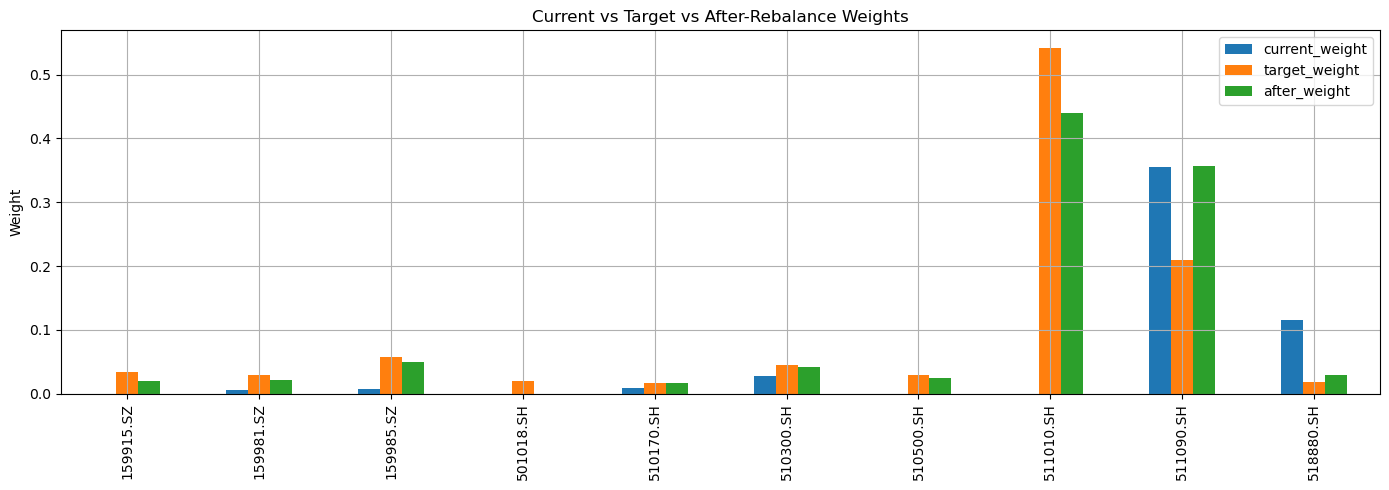

In [29]:

# ========= 图形查看：当前权重 / 目标权重 / 调后权重 =========
compare_weights = pd.DataFrame({
    "current_weight": current_actual_weights,
    "target_weight": target_weights,
    "after_weight": after_weights,
}).fillna(0.0)

display(compare_weights.sort_values("target_weight", ascending=False))

compare_weights.plot(kind="bar", figsize=(14, 5))
plt.title("Current vs Target vs After-Rebalance Weights")
plt.ylabel("Weight")
plt.tight_layout()
plt.show()


In [30]:

# ========= 导出建议 =========
EXPORT_DIR = Path("data/exports")
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

current_summary.to_csv(EXPORT_DIR / "rebalance_current_summary.csv")
target_weight_df.to_csv(EXPORT_DIR / "rebalance_target_weights.csv")
rebalance_table.to_csv(EXPORT_DIR / "rebalance_suggestion.csv")
trades_df.to_csv(EXPORT_DIR / "rebalance_trades_detail.csv", index=False)

print("export done")


export done


In [32]:
# ========= 精简版调仓建议（含标的名） =========
signal_date = pd.Timestamp(latest_signal_date)
signal_date_str = signal_date.strftime("%Y-%m-%d")

# 读取标的名称映射
inst_df = manager.store.get_instruments(listed_only=False)
name_map = dict(zip(inst_df["ts_code"], inst_df["name"]))

# 尝试从交易日历里找下一个交易日
next_trade_date = None
try:
    cal_df = manager.store.get_trade_calendar(
        exchange="SSE",
        start_date=signal_date.strftime("%Y%m%d"),
        end_date="20300101",
        is_open=1,
    )
    future_open_dates = pd.to_datetime(cal_df["cal_date"], format="%Y%m%d", errors="coerce")
    future_open_dates = future_open_dates[future_open_dates > signal_date]
    if len(future_open_dates) > 0:
        next_trade_date = future_open_dates.iloc[0]
except Exception:
    next_trade_date = None


simple_advice = rebalance_table[["current_lots", "after_lots"]].copy()


# 转成展示格式
simple_advice = simple_advice.reset_index().rename(columns={
    "index": "ts_code",
    "current_lots": "调整前手数",
    "after_lots": "调整后手数",
})

# 增加标的名称
simple_advice["name"] = simple_advice["ts_code"].map(name_map)

# 调整列顺序
simple_advice = simple_advice[["ts_code", "name", "调整前手数", "调整后手数"]]

# 手数转整数
simple_advice["调整前手数"] = simple_advice["调整前手数"].astype(int)
simple_advice["调整后手数"] = simple_advice["调整后手数"].astype(int)

print(f"当前读取到的最新市场数据日期：{signal_date_str}")

if next_trade_date is not None:
    print(f"建议于下一个交易日（{next_trade_date.strftime('%Y-%m-%d')}）做如下调整：")
else:
    print("建议于下一个交易日做如下调整：")

display(simple_advice)

当前读取到的最新市场数据日期：2026-03-24
建议于下一个交易日做如下调整：


,ts_code,name,调整前手数,调整后手数
0,159915.SZ,创业板ETF易方达,0,2
1,159981.SZ,能源化工ETF,1,4
2,159985.SZ,豆粕ETF,1,7
3,501018.SH,南方原油LOF,0,0
4,510170.SH,大宗商品ETF,2,4
5,510300.SH,沪深300ETF华泰柏瑞,2,3
6,510500.SH,中证500ETF,0,1
7,511010.SH,国债ETF,0,1
8,511090.SH,30年国债ETF,1,1
9,518880.SH,黄金ETF,4,1
